# PCA through Singular Value Decomposition

In [3]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])

# Center the data (subtract the mean from each feature)
X_centered = X - np.mean(X, axis=0)

# Calculate the covariance matrix:
# For PCA using SVD on the covariance matrix, `R` should be the covariance matrix of the centered data.
# `rowvar=False` indicates that columns represent variables/features.
R = np.cov(X_centered, rowvar=False)

# Calculate the SVD decomposition and new basis vectors:
# For a symmetric matrix like a covariance matrix, U will contain the eigenvectors (principal components)
# D (singular values) are the square roots of the eigenvalues.
# V is typically Vh (conjugate transpose) from np.linalg.svd, and for symmetric real matrices, Vh is U.T
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition

# The columns of U are the principal components (new basis vectors)
u1=U[:,0] # first principal component
u2=U[:,1] # second principal component

print("Original Data X:\n", X)
print("\nCentered Data X_centered:\n", X_centered)
print("\nCovariance Matrix R:\n", R)
print("\nPrincipal Components (Eigenvectors U):\n", U)
print("\nSingular Values (square roots of Eigenvalues D):\n", D)
print("\nFirst Principal Component (u1):\n", u1)
print("\nSecond Principal Component (u2):\n", u2)

# Calculate the coordinates in new orthonormal basis:
# Project the centered data onto the first two principal components
X_pca_coords = X_centered @ U[:, :2]
print("\nCoordinates in new orthonormal basis (first 2 PCs):\n", X_pca_coords)

# Calculate the approximation of the original from new basis (using first 2 PCs)
# Transform back from PCA space to original centered space and then add the mean back
X_approx_centered = X_pca_coords @ U[:, :2].T
X_approx = X_approx_centered + np.mean(X, axis=0)

print("\nApproximation of the original from new basis (using 2 PCs):\n", X_approx)

# Check that you got the original (if all principal components are used for reconstruction)
# For full reconstruction, we project onto all principal components and then transform back
X_full_reconstruction_centered = (X_centered @ U) @ U.T
X_full_reconstruction = X_full_reconstruction_centered + np.mean(X, axis=0)

print("\nFull Reconstruction of Original Data (using all PCs):\n", X_full_reconstruction)

# Verify if full reconstruction is close to original data (within numerical precision)
print("\nIs full reconstruction close to original X?", np.allclose(X, X_full_reconstruction))
# For approximation with fewer PCs, it won't be exactly the original X
print("Is approximation (2 PCs) close to original X?", np.allclose(X, X_approx))

Original Data X:
 [[2 1 0]
 [4 3 0]]

Centered Data X_centered:
 [[-1. -1.  0.]
 [ 1.  1.  0.]]

Covariance Matrix R:
 [[2. 2. 0.]
 [2. 2. 0.]
 [0. 0. 0.]]

Principal Components (Eigenvectors U):
 [[-0.70710678  0.         -0.70710678]
 [-0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]]

Singular Values (square roots of Eigenvalues D):
 [4. 0. 0.]

First Principal Component (u1):
 [-0.70710678 -0.70710678  0.        ]

Second Principal Component (u2):
 [0. 0. 1.]

Coordinates in new orthonormal basis (first 2 PCs):
 [[ 1.41421356  0.        ]
 [-1.41421356  0.        ]]

Approximation of the original from new basis (using 2 PCs):
 [[2. 1. 0.]
 [4. 3. 0.]]

Full Reconstruction of Original Data (using all PCs):
 [[2. 1. 0.]
 [4. 3. 0.]]

Is full reconstruction close to original X? True
Is approximation (2 PCs) close to original X? True


# PCA on Iris data

In [4]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

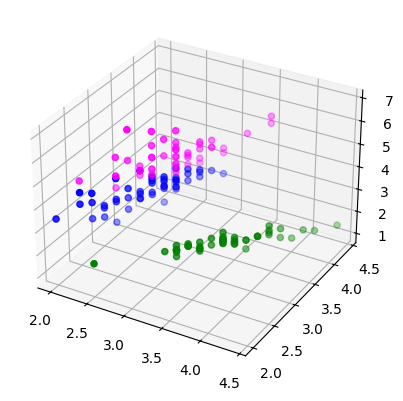

In [5]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


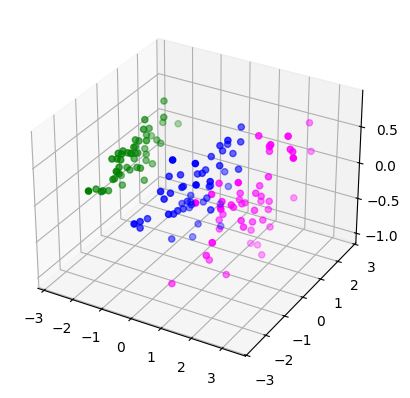

In [7]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition # Import decomposition module
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show()

In [8]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
print("Explained Variance:", pca.explained_variance_)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance: [2.93808505 0.9201649  0.14774182]
Explained Variance Ratio: [0.72962445 0.22850762 0.03668922]


In [ ]:
pca.explained_variance_ratio_

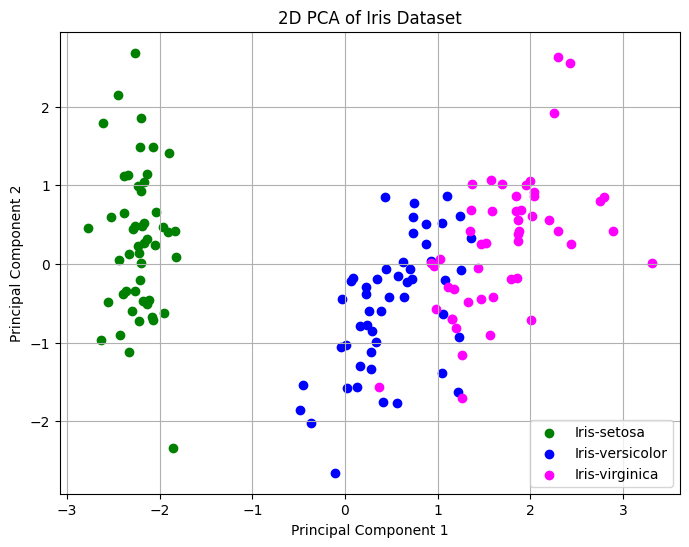

In [9]:
# Plot the principal components in 2D, mark different targets in color
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(Xpca[y==0, 0], Xpca[y==0, 1], color='green', label='Iris-setosa')
plt.scatter(Xpca[y==1, 0], Xpca[y==1, 1], color='blue', label='Iris-versicolor')
plt.scatter(Xpca[y==2, 0], Xpca[y==2, 1], color='magenta', label='Iris-virginica')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

# KNN classifier

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


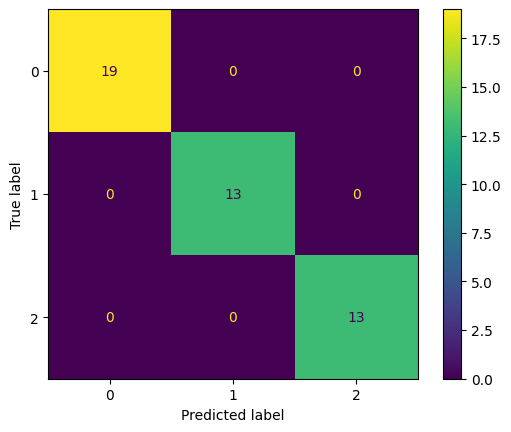

In [10]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, y_train)
Ypred=knn1.predict(X_test)

# Import and show confusion matrix
cm = confusion_matrix(y_test, Ypred)
print("Confusion Matrix:\n", cm)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
import matplotlib.pyplot as plt
plt.show()

Confusion Matrix for PCA (2 components) data:
 [[19  0  0]
 [ 0 11  2]
 [ 0  0 13]]


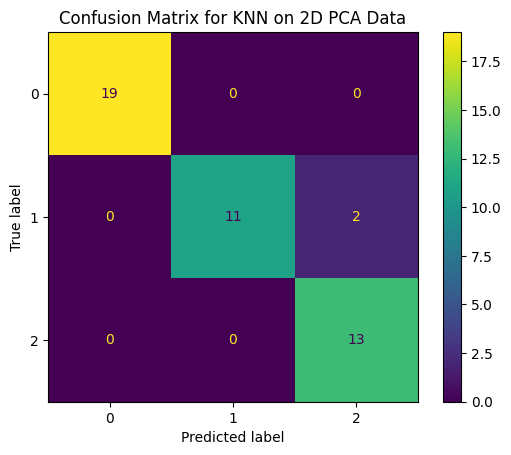

In [11]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use only the first two principal components from Xpca
X_pca_2d = Xpca[:, :2]

# Split the PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_2d, y, test_size=0.3, random_state=42)

# Train KNN classifier on the 2D PCA data
knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train_pca, y_train_pca)
Ypred_pca = knn_pca.predict(X_test_pca)

# Import and show confusion matrix for PCA data
cm_pca = confusion_matrix(y_test_pca, Ypred_pca)
print("Confusion Matrix for PCA (2 components) data:\n", cm_pca)

# Display the confusion matrix plot
ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca)
plt.title('Confusion Matrix for KNN on 2D PCA Data')
plt.show()


Confusion Matrix for original 2D data (first two columns):
 [[19  0  0]
 [ 0  7  6]
 [ 0  5  8]]


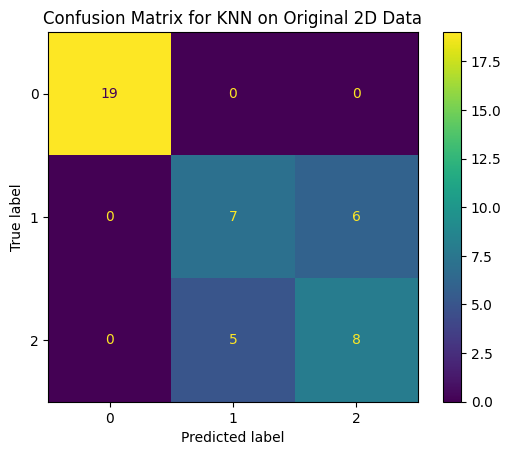

In [12]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use only the first two columns of the original X data
X_2d = X[:, :2]

# Split the 2D original data into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42)

# Train KNN classifier on the 2D original data
knn_2d = KNeighborsClassifier(n_neighbors=3)
knn_2d.fit(X_train_2d, y_train_2d)
Ypred_2d = knn_2d.predict(X_test_2d)

# Import and show confusion matrix for 2D original data
cm_2d = confusion_matrix(y_test_2d, Ypred_2d)
print("Confusion Matrix for original 2D data (first two columns):\n", cm_2d)

# Display the confusion matrix plot
ConfusionMatrixDisplay.from_predictions(y_test_2d, Ypred_2d)
plt.title('Confusion Matrix for KNN on Original 2D Data')
plt.show()